2026-02-23 23:15:37.716809: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-23 23:15:38.097325: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-23 23:15:39.608765: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Loading data...
Reading dataset...
Loading 1 files from /home/abbatenicolas/data...


/home/abbatenicolas/miniconda3/envs/tf/lib/python3.9/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'rasterio' loading failed:
libnetcdf.so.19: cannot open shared object file: No such file or directory
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


Links without images (2022): 0 out of 449727
Remaining links for train/test (2022): 449727
Datasets loaded!
Data loaded successfully!


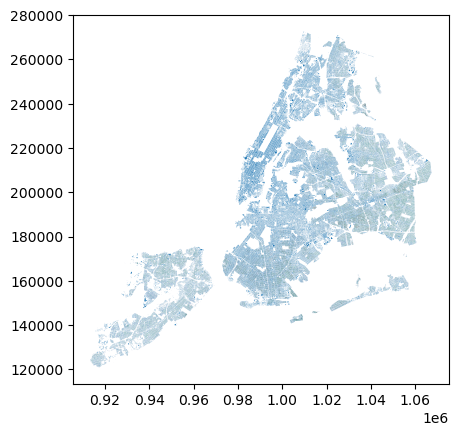

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import the project's modules
import src.main as main
import src.build_dataset as build_dataset
import src.geo_utils as geo_utils
from src.utils.paths import PROCESSED_DATA_DIR

# 1. Load the datasets and the dataframe
years = [2022] # Adjust depending on the years you want to test
print("Loading data...")
datasets_all_years, extents_all_years, df = main.open_datasets(sat_data="aerial", years=years)
print("Data loaded successfully!")

In [2]:
import tensorflow as tf
# 2. Load the generic Keras model (Replace with your actual path!)
MODEL_PATH = r"/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/models/effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling.keras"
print(f"Loading model from {MODEL_PATH}...")
try:
    model = tf.keras.models.load_model(MODEL_PATH)
    print("Model loaded successfully!")
except Exception as e:
    print(f"Warning: Could not load model. Error: {e}")
    model = None

Loading model from /mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/models/effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling.keras...


I0000 00:00:1771901455.082622  121211 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1656 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:02:00.0, compute capability: 8.6


Model loaded successfully!


In [3]:
df

,capture_da,boroname,index_righ,GEOID,STATE,COUNTY,TRACT,NAME,CNTY_FIPS,avg_hh_inc,geometry,avg_hh_inc_log,var,dataset_2022
0,None,Queens,74993,36081157901,36,081,157901,Census Tract 1579.01,36081,122969,"POLYGON ((1067053.173 209139.295, 1067044.762 ...",11.719688,0.918346,nyc_2022.zarr
1,None,Queens,74993,36081157901,36,081,157901,Census Tract 1579.01,36081,122969,"POLYGON ((1066993.434 211949.564, 1067030.554 ...",11.719688,0.918346,nyc_2022.zarr
2,None,Queens,74993,36081157901,36,081,157901,Census Tract 1579.01,36081,122969,"POLYGON ((1066744.615 209584.918, 1066783.937 ...",11.719688,0.918346,nyc_2022.zarr
3,None,Queens,74993,36081157901,36,081,157901,Census Tract 1579.01,36081,122969,"POLYGON ((1066671.441 209426.912, 1066706.044 ...",11.719688,0.918346,nyc_2022.zarr
4,None,Queens,74995,36081157903,36,081,157903,Census Tract 1579.03,36081,104135,"POLYGON ((1066621.379 208092.188, 1066602.7 20...",11.553443,0.455238,nyc_2022.zarr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
457302,7/25/2019-7/30/2019,Staten Island,64529,36085024401,36,085,024401,Census Tract 244.01,36085,127250,"POLYGON ((914278.373 123196.517, 914236.906 12...",11.753909,1.013677,nyc_2022.zarr
457303,7/25/2019-7/30/2019,Staten Island,64529,36085024401,36,085,024401,Census Tract 244.01,36085,127250,"POLYGON ((914230.566 124269.59, 914264.523 124...",11.753909,1.013677,nyc_2022.zarr
457304,7/25/2019-7/30/2019,Staten Island,64529,36085024401,36,085,024401,Census Tract 244.01,36085,127250,"POLYGON ((914203.412 124013.548, 914200.86 123...",11.753909,1.013677,nyc_2022.zarr
457305,7/25/2019-7/30/2019,Staten Island,64529,36085024401,36,085,024401,Census Tract 244.01,36085,127250,"POLYGON ((913923.046 124090.499, 913924.229 12...",11.753909,1.013677,nyc_2022.zarr


/home/abbatenicolas/miniconda3/envs/tf/lib/python3.9/site-packages/tensorflow/python/framework/ops.py:315: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(self._numpy())


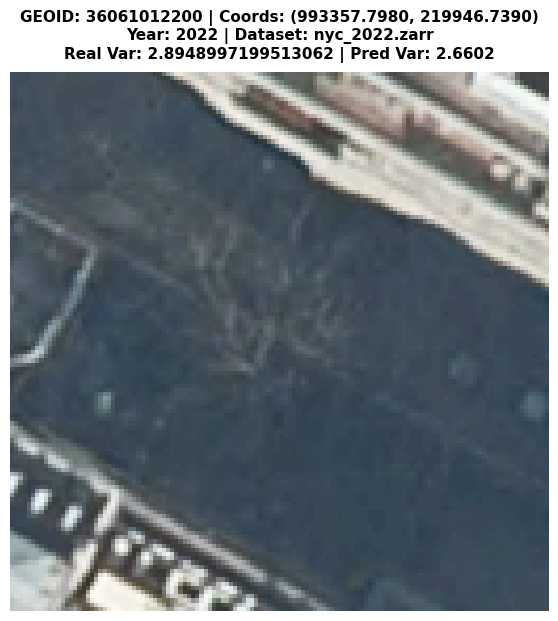

Processed Index 11523 -> Real: 2.8948997199513062 | Pred: 2.66015625


/home/abbatenicolas/miniconda3/envs/tf/lib/python3.9/site-packages/tensorflow/python/framework/ops.py:315: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(self._numpy())


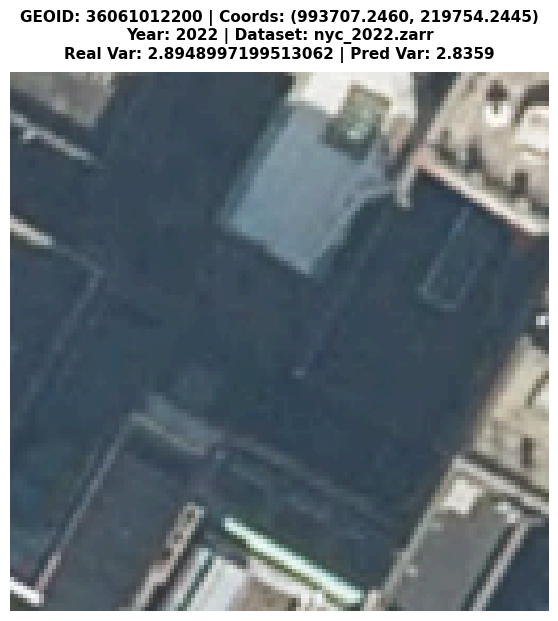

Processed Index 12190 -> Real: 2.8948997199513062 | Pred: 2.8359375


/home/abbatenicolas/miniconda3/envs/tf/lib/python3.9/site-packages/tensorflow/python/framework/ops.py:315: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(self._numpy())


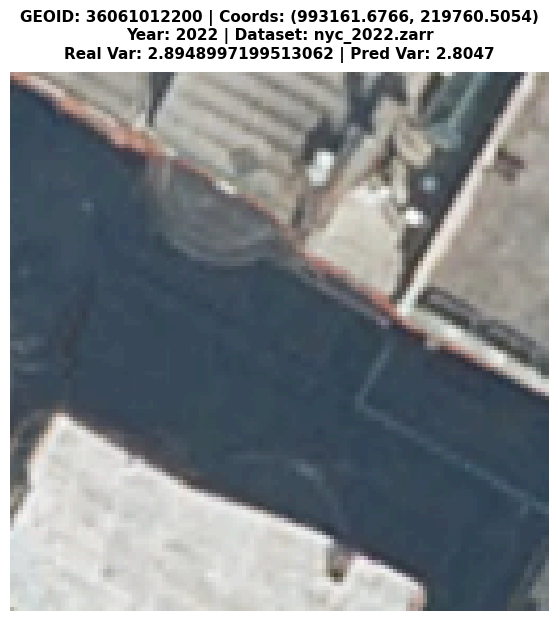

Processed Index 27379 -> Real: 2.8948997199513062 | Pred: 2.8046875


/home/abbatenicolas/miniconda3/envs/tf/lib/python3.9/site-packages/tensorflow/python/framework/ops.py:315: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(self._numpy())


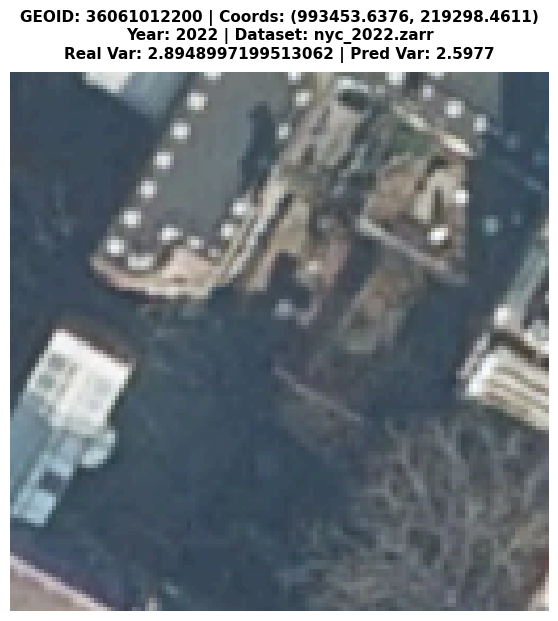

Processed Index 86087 -> Real: 2.8948997199513062 | Pred: 2.59765625


/home/abbatenicolas/miniconda3/envs/tf/lib/python3.9/site-packages/tensorflow/python/framework/ops.py:315: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(self._numpy())


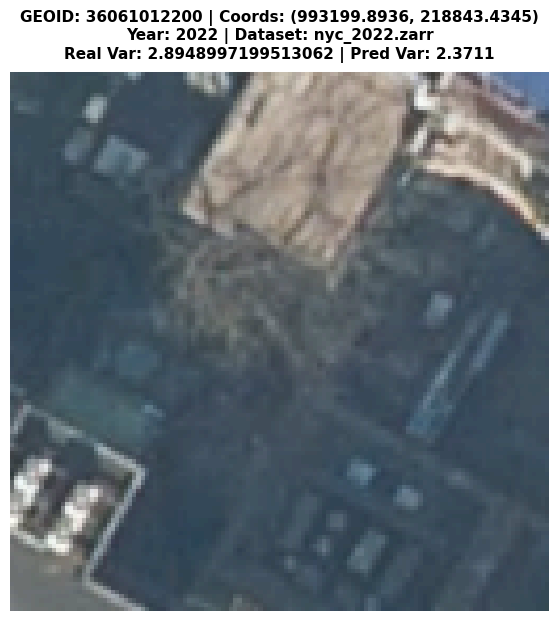

Processed Index 86409 -> Real: 2.8948997199513062 | Pred: 2.37109375


/home/abbatenicolas/miniconda3/envs/tf/lib/python3.9/site-packages/tensorflow/python/framework/ops.py:315: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(self._numpy())


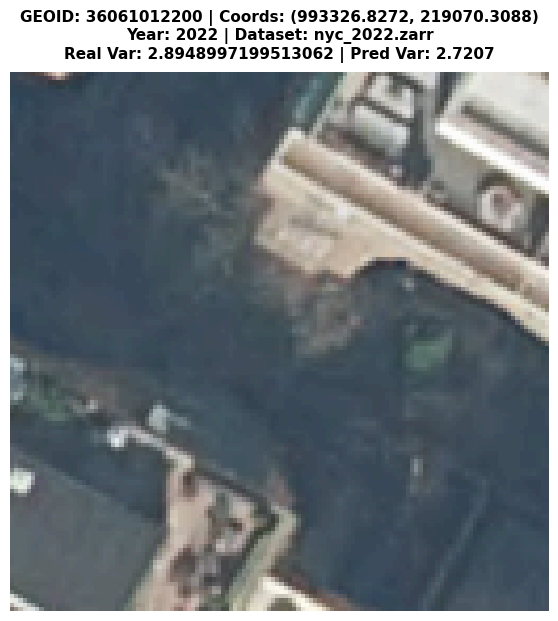

Processed Index 119841 -> Real: 2.8948997199513062 | Pred: 2.720703125


/home/abbatenicolas/miniconda3/envs/tf/lib/python3.9/site-packages/tensorflow/python/framework/ops.py:315: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(self._numpy())


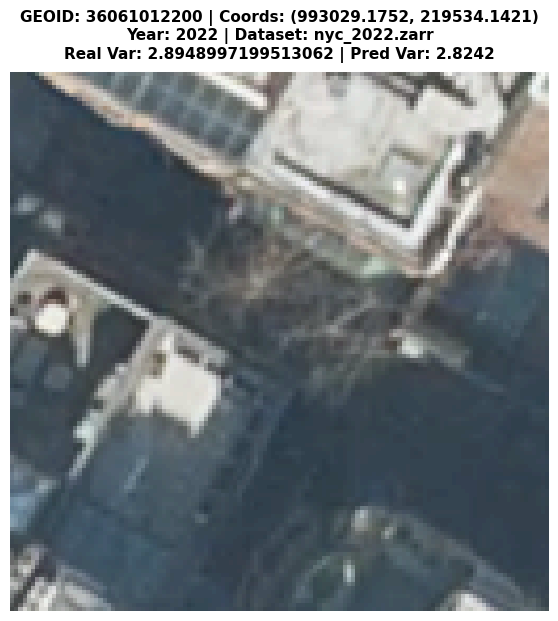

Processed Index 192680 -> Real: 2.8948997199513062 | Pred: 2.82421875


/home/abbatenicolas/miniconda3/envs/tf/lib/python3.9/site-packages/tensorflow/python/framework/ops.py:315: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(self._numpy())


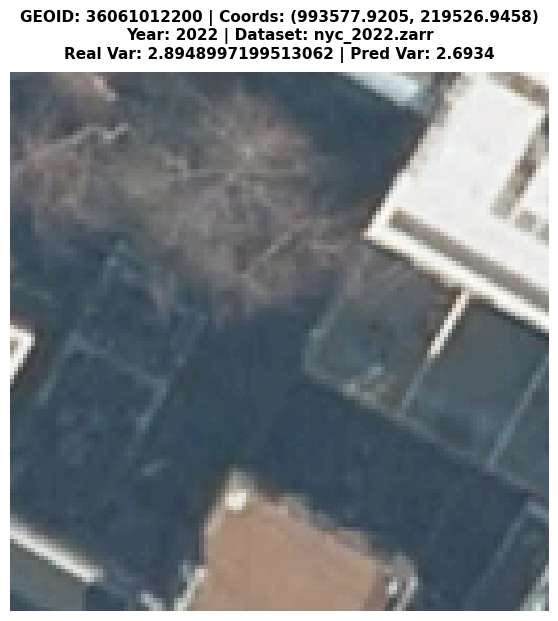

Processed Index 240518 -> Real: 2.8948997199513062 | Pred: 2.693359375


/home/abbatenicolas/miniconda3/envs/tf/lib/python3.9/site-packages/tensorflow/python/framework/ops.py:315: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(self._numpy())


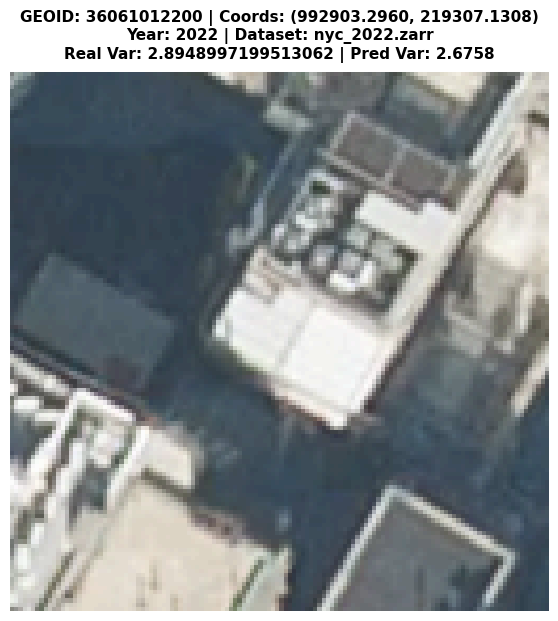

Processed Index 274263 -> Real: 2.8948997199513062 | Pred: 2.67578125


/home/abbatenicolas/miniconda3/envs/tf/lib/python3.9/site-packages/tensorflow/python/framework/ops.py:315: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(self._numpy())


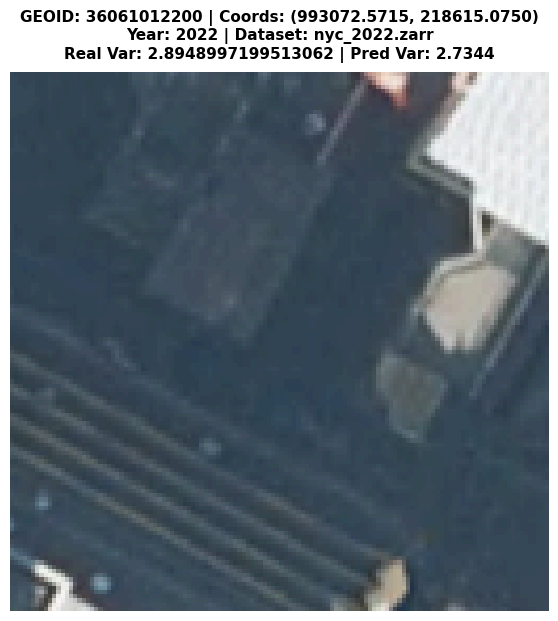

Processed Index 336028 -> Real: 2.8948997199513062 | Pred: 2.734375


/home/abbatenicolas/miniconda3/envs/tf/lib/python3.9/site-packages/tensorflow/python/framework/ops.py:315: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(self._numpy())


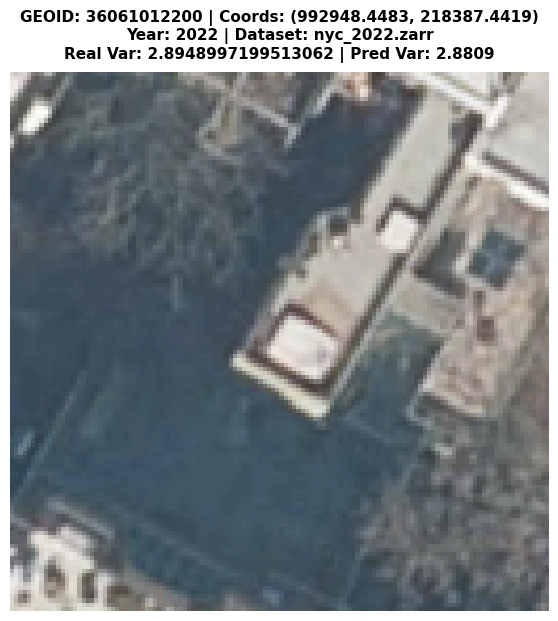

Processed Index 361445 -> Real: 2.8948997199513062 | Pred: 2.880859375


/home/abbatenicolas/miniconda3/envs/tf/lib/python3.9/site-packages/tensorflow/python/framework/ops.py:315: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(self._numpy())


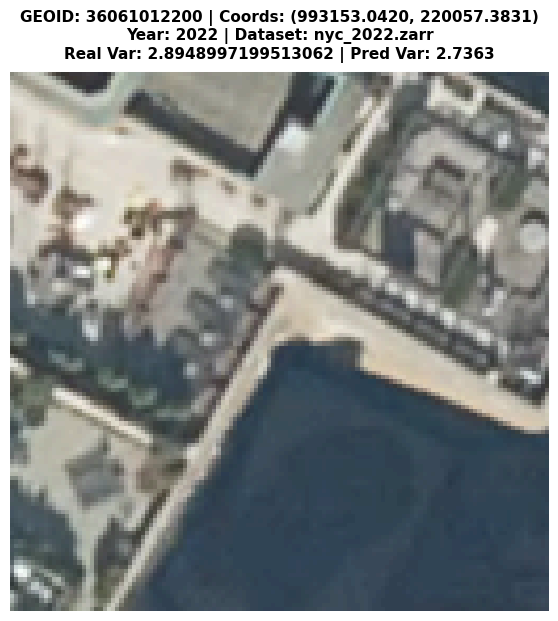

Processed Index 386778 -> Real: 2.8948997199513062 | Pred: 2.736328125


/home/abbatenicolas/miniconda3/envs/tf/lib/python3.9/site-packages/tensorflow/python/framework/ops.py:315: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(self._numpy())


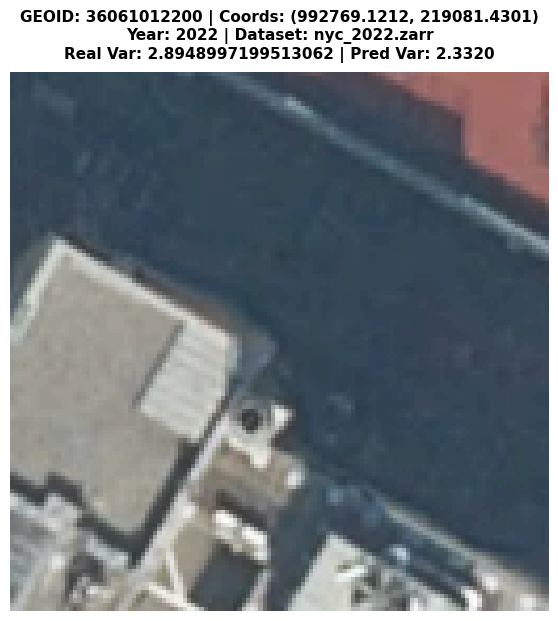

Processed Index 386803 -> Real: 2.8948997199513062 | Pred: 2.33203125


/home/abbatenicolas/miniconda3/envs/tf/lib/python3.9/site-packages/tensorflow/python/framework/ops.py:315: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(self._numpy())


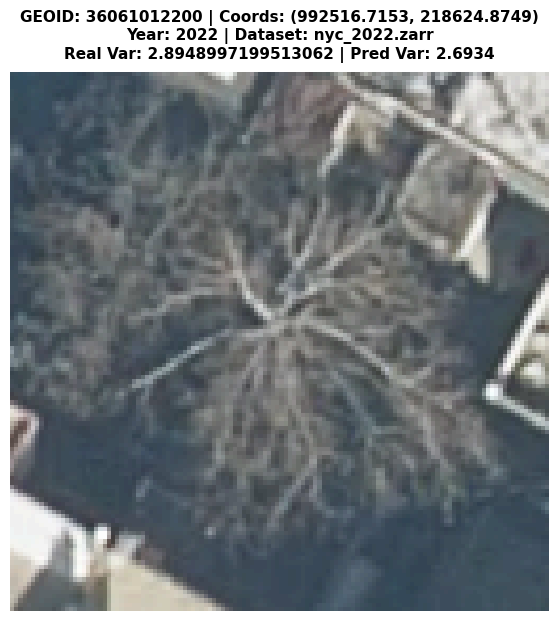

Processed Index 429447 -> Real: 2.8948997199513062 | Pred: 2.693359375


/home/abbatenicolas/miniconda3/envs/tf/lib/python3.9/site-packages/tensorflow/python/framework/ops.py:315: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(self._numpy())


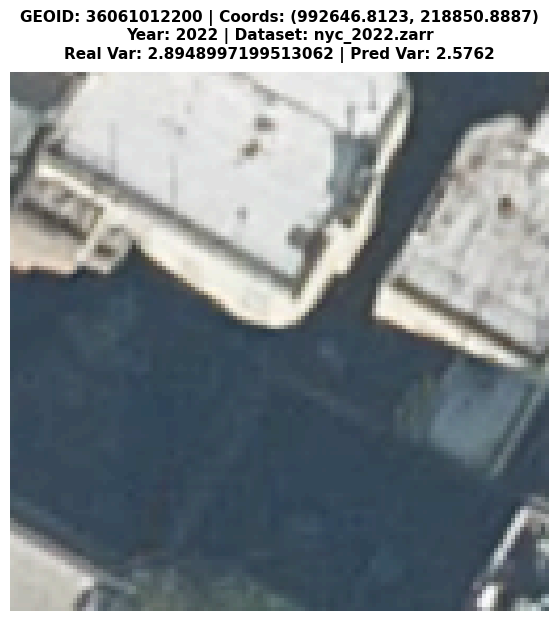

Processed Index 454884 -> Real: 2.8948997199513062 | Pred: 2.576171875

Prediction extraction complete. Review the outputs in the debug folder.


In [11]:
# Configuration matching main.py
image_size = 128 
resizing_size = 128
nbands = 4
stacked_images = [1, 4] 
available_years = list(datasets_all_years.keys())

# Take a random sample of rows to verify
sample_size = 10
# df_sample = df.sample(sample_size, random_state=42)
df_sample = df[df.GEOID == "36061012200"]

save_dir = PROCESSED_DATA_DIR / "debug_ingestion_predictions"
os.makedirs(save_dir, exist_ok=True)

for idx, row in df_sample.iterrows():
    # Retrieve identification
    geoid = row.get("GEOID", "Unknown")
    
    # Extract the REAL value (replace "var" if your target column is named differently)
    real_value = row.get("var", "N/A") 
    
    # 1. Force the centroid geometry instead of the full polygon
    polygon = row["geometry"]
    centroid_geom = polygon.centroid
    coords = (centroid_geom.x, centroid_geom.y)
    
    # Pick a random year identically to get_mini_batch_data
    batch_year = random.choice(available_years)
    primary_dataset = datasets_all_years[batch_year]
    dataset_name = row[f"dataset_{batch_year}"]
    
    if pd.isna(dataset_name):
        print(f"Skipping Index {idx}: No dataset assignment for year {batch_year}")
        continue
        
    link_dataset = primary_dataset[dataset_name]
    
    try:
        # Pass the CENTROID Point rather than the whole polygon
        image, _ = geo_utils.stacked_image_from_census_tract(
            dataset=link_dataset,
            polygon=centroid_geom,  # <-- Forcing the centroid here
            img_size=image_size,
            n_bands=nbands,
            stacked_images=stacked_images,
        )
        
        # Apply the exact validation and resizing used in training
        total_bands = nbands * len(stacked_images)
        target_shape = (total_bands, image_size, image_size)
        
        if image.shape != target_shape:
             print(f"Shape mismatch at Index {idx}. Yielding blank image.")
             image = np.zeros(shape=(resizing_size, resizing_size, total_bands))
        else:
             image = geo_utils.process_image(image, resizing_size)
        
        # 2. Get the model prediction
        predicted_value = "N/A"
        if model is not None:
            # Expand dimensions to create a batch of 1: shape becomes (1, 128, 128, total_bands)
            input_tensor = np.expand_dims(image, axis=0)
            pred_array = model.predict(input_tensor, verbose=0)
            
            # Assuming a standard regression output shape of (1, 1)
            predicted_value = float(pred_array[0][0])
            
        # Plotting the image (Visualizing the first 3 bands as RGB for validation)
        plt.figure(figsize=(7, 7))
        vis_image = image[:, :, :3]
        
        if vis_image.max() > 1.0:
            vis_image = vis_image.astype(float) / 255.0
            
        plt.imshow(vis_image)
        
        # 3. Document everything in the title
        title_text = (
            f"GEOID: {geoid} | Coords: ({coords[0]:.4f}, {coords[1]:.4f})\n"
            f"Year: {batch_year} | Dataset: {dataset_name}\n"
            f"Real Var: {real_value} | Pred Var: "
            f"{predicted_value:.4f}" if isinstance(predicted_value, float) else f"{predicted_value}"
        )
        
        plt.title(title_text, fontsize=11, fontweight='bold', pad=10)
        plt.axis('off')
        
        filename = save_dir / f"idx_{idx}_geoid_{geoid}.png"
        plt.savefig(filename, bbox_inches='tight')
        plt.show()
        plt.close()
        
        print(f"Processed Index {idx} -> Real: {real_value} | Pred: {predicted_value}")
        
    except Exception as e:
        print(f"Failed to process Index {idx} (GEOID: {geoid}): {e}")

print("\nPrediction extraction complete. Review the outputs in the debug folder.")